In [1]:
#── Standard library ─────────────────────────────────────────────────────────
import re
import string
import warnings
from collections import Counter, defaultdict
 
# ── Data manipulation ─────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
 
# ── Visualization ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
 
# ── NLP — NLTK ────────────────────────────────────────────────────────────────
import nltk
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords
 
# ── NLP — Language detection ──────────────────────────────────────────────────
from langdetect import detect
from langdetect import DetectorFactory
DetectorFactory.seed = 42
# ── NLP — Sentence embeddings ─────────────────────────────────────────────────
from sentence_transformers import SentenceTransformer
 
# ── Scikit-learn — Feature extraction ────────────────────────────────────────
from sklearn.feature_extraction.text import (
    CountVectorizer,
    TfidfVectorizer,
)
 
# ── Scikit-learn — Dimensionality reduction ───────────────────────────────────
from sklearn.decomposition import (
    TruncatedSVD,
    LatentDirichletAllocation,
)
 
# ── Scikit-learn — Clustering ─────────────────────────────────────────────────
from sklearn.cluster import (
    KMeans,
    AgglomerativeClustering,
)
 
# ── Scikit-learn — Evaluation & preprocessing ────────────────────────────────
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import Normalizer
from sklearn.model_selection import train_test_split
 
# ── Display ───────────────────────────────────────────────────────────────────
from tabulate import tabulate

Affichage et pretraitement de donnes

In [2]:
# Loading the data sata and first few values
df = pd.read_csv("train.csv") 
dfth=df.copy()
print(f"Shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nFirst few rows:")
df.head()



Shape: (3512, 2)

Columns: ['Context', 'Response']

First few rows:


,Context,Response
0,I'm going through some things with my feelings...,"If everyone thinks you're worthless, then mayb..."
1,I'm going through some things with my feelings...,"Hello, and thank you for your question and see..."
2,I'm going through some things with my feelings...,First thing I'd suggest is getting the sleep y...
3,I'm going through some things with my feelings...,Therapy is essential for those that are feelin...
4,I'm going through some things with my feelings...,I first want to let you know that you are not ...


In [3]:
# --------------------------
# text cleaning + removing stopwords
# --------------------------
stop_words = set(stopwords.words('english'))
def clean_text(text):
    text = str(text).lower()                     
    text = re.sub(r"[\r\n]+", " ", text)            
    text = re.sub(r"[^a-z0-9\s]", "", text)         
    text = re.sub(r"\s+", " ", text)                
    words = text.strip().split()
    words = [w for w in words if w not in stop_words]  
    return " ".join(words)

def is_english(text):
    try:
        return detect(str(text)) == 'en'
    except:
        return False  
    
# 1. Remove missing responses
df = df.dropna(subset=["Response"])
# 2. Remove exact duplicated conversations
df = df.drop_duplicates(subset=["Context", "Response"], keep="first")
print("Without duplicate conversation",df.shape)
# 3.Clean text
df['Context'] = df['Context'].apply(clean_text)
df['Response'] = df['Response'].apply(clean_text)
# 4.Only english text
mask = df['Context'].apply(is_english) & df['Response'].apply(is_english)
df = df[mask].reset_index(drop=True)

print(f"Après filtres : {df.shape[0]} lignes")

Without duplicate conversation (2748, 2)
Après filtres : 2594 lignes


Number of patients and therapist

This dataset contains no identifiers for either patients or therapists and was
intentionally anonymized, so there is no way to precisely know how many there
are. However, we can still make an educated guess.

- For patients, we assume that 1 unique question = 1 distinct user. This is
  reasonable since two different people are very unlikely to write exactly the
  same question word for word.

- As for therapists, even though this dataset is supposedly anonymized, we can
  still find signatures in some responses, which will be our best approach.
  Stylometry is not viable here since the texts are too short, and LDA would
  group responses by theme which depends on the patient's question  rather
  than by author.

In [4]:
#Patients
df_users = df.drop_duplicates(subset=["Context"], keep="first").copy()
n_users  = len(df_users)
print(f"Number of patients (unique questions) : {n_users}")
 

Number of patients (unique questions) : 796


In [5]:
# Two regex patterns to find therapist signatures in response text
# Pattern 1 : "First Last, CREDENTIAL"  e.g. "Robin Landwehr, DBH, LPC"
# Pattern 2 : closing formula + name    e.g. "Warm regards, Mirella"
PATTERNS = [
    r"\b([A-Z][a-z]+ [A-Z][a-z]+(?:\s[A-Z][a-z]+)?),?\s*"
    r"(?:M\.?[AS]\.?|L[A-Z]{2,4}|PhD|DBH|LPCC|LMHC|LMSW|LMAC|MFT|LPC|LCSW|BCBA|NCC|MAC|Psy\.?D|Ed\.?D|R\.?N)\b",
    r"(?:Warm regards|Sincerely|In [Ss]olidarity)[,!]?\s*[-]?\s*\n?\s*"
    r"([A-Z][a-z]+(?:\s[A-Z][a-z]+)?(?:~[A-Z][a-z ]+)?)",
]

# Words that match patterns but are not therapist names
BLACKLIST = {"Wishes", "Best", "Good", "Thank", "Many", "Stan Tatkin", "Rheals"}

# Map name variants to one canonical name
NORMALIZE = {"Robin J. Landwehr": "Robin Landwehr", "Landwehr": "Robin Landwehr"}

def extract_sig(text):
    # Return therapist name from response, or None if no signature found
    for pat in PATTERNS:
        m = re.findall(pat, str(text), re.MULTILINE)
        if m:
            name = m[-1].strip().split("~")[0].strip()  # remove cabinet suffix
            name = re.sub(r"\s+", " ", name)             # normalize whitespace
            if name not in BLACKLIST and 3 < len(name) < 40:
                return NORMALIZE.get(name, name)
    return None

# Apply to all responses
df["therapist"]    = dfth["Response"].apply(extract_sig)

# Keep only signed responses
df_therapists      = df[df["therapist"].notna()].copy()
n_therapists       = df_therapists["therapist"].nunique()   # distinct names
n_signed_responses = len(df_therapists)                     # total signed

print(f"Number of therapists identified (signatures) : {n_therapists}")
print(f"Signed responses found                       : {n_signed_responses} / {len(df)}")
print(f"Coverage                                     : {n_signed_responses/len(df)*100:.1f}%")


print(f"\nNote: {n_therapists} is a confirmed minimum — total number unknown (anonymized dataset)")
 

Number of therapists identified (signatures) : 12
Signed responses found                       : 31 / 2594
Coverage                                     : 1.2%

Note: 12 is a confirmed minimum — total number unknown (anonymized dataset)


3. Summary Statistics Table

In [6]:
n_total_exchanges   = len(df)
n_missing           = df["Response"].isna().sum()
 
responses_per_user  = df.groupby("Context").size()
avg_resp_per_user   = responses_per_user.mean()
med_resp_per_user   = responses_per_user.median()
max_resp_per_user   = responses_per_user.max()
 
therapist_counts       = df_therapists.groupby("therapist").size()
avg_conv_per_therapist = therapist_counts.mean()
 
df["ctx_words"]  = df["Context"].str.split().str.len()
df["resp_words"] = df["Response"].str.split().str.len()
 
ctx_avg  = df_users["Context"].str.split().str.len().mean()
ctx_med  = df_users["Context"].str.split().str.len().median()
ctx_min  = df_users["Context"].str.split().str.len().min()
ctx_max  = df_users["Context"].str.split().str.len().max()
 
resp_avg = df["resp_words"].mean()
resp_med = df["resp_words"].median()
resp_min = df["resp_words"].min()
resp_max = df["resp_words"].max()
 
# ── Overview table ────────────────────────────────────────────────────────────
SEP = "─" * 72
print(SEP)
print("  SUMMARY STATISTICS — NLP Mental Health Conversations")
print(SEP)
 
table_overview = [
    ["Number of patients (unique questions)",       f"{n_users:,}",              "1 unique Context = 1 user"],
    ["Number of therapists identified",             f"{n_therapists}",           f"Signatures found in {n_signed_responses} responses ({n_signed_responses/n_total_exchanges*100:.1f}%)"],
    ["Total exchanges",                             f"{n_total_exchanges:,}",    "After cleaning"],
    ["Responses per patient — mean",                f"{avg_resp_per_user:.1f}",  ""],
    ["Responses per patient — median",              f"{med_resp_per_user:.0f}",  ""],
    ["Responses per patient — max",                 f"{max_resp_per_user}",      ""],
    ["Conversations per therapist (identified only)", f"{avg_conv_per_therapist:.1f}", f"Based on {n_therapists} identified therapists"],
]
print(tabulate(table_overview,
               headers=["Indicator", "Value", "Note"],
               tablefmt="rounded_outline",
               colalign=("left", "right", "left")))
 

# ── Exchange length table ──────────────────────────────────────────────────────
print("\n")
table_length = [
    [f"Patient question  (n={n_users})",         f"{ctx_avg:.1f}",  f"{ctx_med:.0f}", f"{int(ctx_min)}", f"{int(ctx_max)}"],
    [f"Therapist response (n={n_total_exchanges})", f"{resp_avg:.1f}", f"{resp_med:.0f}", f"{int(resp_min)}", f"{int(resp_max)}"],
    ["Ratio response / question",                  f"×{resp_avg/ctx_avg:.1f}", "—", "—", "—"],
]
print(tabulate(table_length,
               headers=["", "Mean", "Median", "Min", "Max"],
               tablefmt="rounded_outline",
               colalign=("left", "right", "right", "right", "right")))
 

# ── Responses per patient distribution ────────────────────────────────────────
print("\n")
buckets = {
    "1 response":   (responses_per_user == 1).sum(),
    "2 responses":  (responses_per_user == 2).sum(),
    "3 responses":  (responses_per_user == 3).sum(),
    "4 responses":  (responses_per_user == 4).sum(),
    "5–9 responses":((responses_per_user >= 5) & (responses_per_user <= 9)).sum(),
    "10+ responses":(responses_per_user >= 10).sum(),
}
table_dist = [
    [label, count, f"{count / n_users * 100:.1f}%"]
    for label, count in buckets.items()
]
print(tabulate(table_dist,
               headers=["Responses per patient", "Patients", "Share"],
               tablefmt="rounded_outline",
               colalign=("left", "right", "right")))
 
# ── Identified therapists detail ──────────────────────────────────────────────
print("\n")
therapist_counts_df = (
    therapist_counts
    .reset_index()
    .set_axis(["Therapist", "Signed responses"], axis=1)
    .sort_values("Signed responses", ascending=False)
)
print(tabulate(
    therapist_counts_df.values.tolist(),
    headers=["Therapist", "Signed responses"],
    tablefmt="rounded_outline",
    colalign=("left", "right")))
 
print(f"\n    {n_total_exchanges - n_signed_responses} responses ({(n_total_exchanges - n_signed_responses)/n_total_exchanges*100:.1f}%) are anonymous — total therapist count unknown.")
 

# ── Stopwords (NLTK) ──────────────────────────────────────────────────────────
STOPWORDS = set(stopwords.words("english"))
print(f"NLTK stopwords loaded : {len(STOPWORDS)} words")
 
# ── Tokenization function ─────────────────────────────────────────────────────
def tokenize(text):
    text = str(text).lower()
    text = re.sub(r"[^a-z\s]", " ", text)
    return [t for t in text.split() if t not in STOPWORDS and len(t) > 2]
 
# ── Compute word frequencies ──────────────────────────────────────────────────
 
# Per conversation (Context + Response combined)
conv_tokens = (df["Context"] + " " + df["Response"]).apply(tokenize)
freq_conv   = Counter(t for tokens in conv_tokens for t in tokens)
 
# Per patient (796 unique Context)
freq_patients = Counter(t for txt in df_users["Context"] for t in tokenize(txt))
 
# Per therapist (signed responses only — 12 therapists, 36 responses)
freq_therapists = Counter(t for txt in df_therapists["Response"] for t in tokenize(txt))
 
# Global vocabulary
all_tokens  = [t for txt in df["Context"].tolist() + df["Response"].tolist() for t in tokenize(txt)]
global_freq = Counter(all_tokens)
 
total_conv  = sum(freq_conv.values())
total_pat   = sum(freq_patients.values())
total_ther  = sum(freq_therapists.values())
 
print(f"Total unique tokens  : {len(global_freq):,}")
print(f"Total tokens patients   : {total_pat:,}")
print(f"Total tokens therapists : {total_ther:,}")
print(f"Total tokens conv.      : {total_conv:,}")
 

# ── Build lexical dictionary (top 50 words) ───────────────────────────────────
TOP_N     = 50
top_words = [w for w, _ in global_freq.most_common(TOP_N)]
 
lexicon = []
for rank, word in enumerate(top_words, 1):
    lexicon.append({
        "rank":            rank,
        "word":            word,
        "freq_global":     global_freq[word],
        "freq_conv":       freq_conv[word],
        "freq_patients":   freq_patients[word],
        "pct_patients":    round(freq_patients[word]   / total_pat  * 100, 2),
        "freq_therapists": freq_therapists[word],
        "pct_therapists":  round(freq_therapists[word] / total_ther * 100, 2),
    })
 
df_lex = pd.DataFrame(lexicon)
 
# ── Table 1 : full lexical statistics ────────────────────────────────────────
print(SEP)
print("  LEXICAL DICTIONARY — Top 50 words")
print(SEP)
 
print(tabulate(
    df_lex[["rank","word","freq_global","freq_conv",
            "freq_patients","pct_patients",
            "freq_therapists","pct_therapists"]].values.tolist(),
    headers=["#", "Word", "Global freq", "Freq/conv",
             "Freq patients", "% patients",
             "Freq therapists", "% therapists"],
    tablefmt="rounded_outline",
    colalign=("right","left","right","right","right","right","right","right"),
))
 
# ── Table 2 : words dominant in patients ─────────────────────────────────────
print("\n")
df_lex["ratio_pat"] = df_lex["freq_patients"] / (df_lex["freq_therapists"] + 1)
top_pat = df_lex.sort_values("ratio_pat", ascending=False).head(15)
 
print(tabulate(
    top_pat[["word","freq_patients","freq_therapists","ratio_pat"]]
           .round({"ratio_pat": 1}).values.tolist(),
    headers=["Word", "Freq patients", "Freq therapists", "Ratio P/T"],
    tablefmt="rounded_outline",
    colalign=("left","right","right","right"),
))
 
# ── Table 3 : words dominant in therapists ────────────────────────────────────
print("\n")
df_lex["ratio_ther"] = df_lex["freq_therapists"] / (df_lex["freq_patients"] + 1)
top_ther = df_lex.sort_values("ratio_ther", ascending=False).head(15)
 
print(tabulate(
    top_ther[["word","freq_therapists","freq_patients","ratio_ther"]]
            .round({"ratio_ther": 2}).values.tolist(),
    headers=["Word", "Freq therapists", "Freq patients", "Ratio T/P"],
    tablefmt="rounded_outline",
    colalign=("left","right","right","right"),
))
 
print(f"\n   Therapist frequencies are based on {n_signed_responses} signed responses only ({n_therapists} therapists).")
print(f"     Ratios should be interpreted with caution given the low coverage (1.5%).")
 
# ── Optional export ───────────────────────────────────────────────────────────
# df_lex.to_csv("lexical_dictionary.csv", index=False)

────────────────────────────────────────────────────────────────────────
  SUMMARY STATISTICS — NLP Mental Health Conversations
────────────────────────────────────────────────────────────────────────
╭───────────────────────────────────────────────┬─────────┬─────────────────────────────────────────╮
│ Indicator                                     │   Value │ Note                                    │
├───────────────────────────────────────────────┼─────────┼─────────────────────────────────────────┤
│ Number of patients (unique questions)         │     796 │ 1 unique Context = 1 user               │
│ Number of therapists identified               │      12 │ Signatures found in 31 responses (1.2%) │
│ Total exchanges                               │    2594 │ After cleaning                          │
│ Responses per patient — mean                  │     3.3 │                                         │
│ Responses per patient — median                │       2 │                          

Indentfying major subjects

Lexicon

╭───────────────┬─────────────────┬────────────────╮
│ Topic         │   Conversations │   % of dataset │
├───────────────┼─────────────────┼────────────────┤
│ Relationships │            1102 │          42.5% │
│ Family        │             846 │          32.6% │
│ Anxiety       │             547 │          21.1% │
│ Work/School   │             521 │          20.1% │
│ Depression    │             406 │          15.7% │
│ Other         │             378 │          14.6% │
│ Sleep         │             282 │          10.9% │
│ Anger         │             221 │           8.5% │
│ Trauma/PTSD   │             203 │           7.8% │
│ Addiction     │             150 │           5.8% │
│ Self-esteem   │             122 │           4.7% │
│ Loneliness    │             118 │           4.5% │
│ Suicidal      │              96 │           3.7% │
╰───────────────┴─────────────────┴────────────────╯

Conversations with multiple topics : 1388  (53.5%)
Conversations with single topic    : 1206  (46.

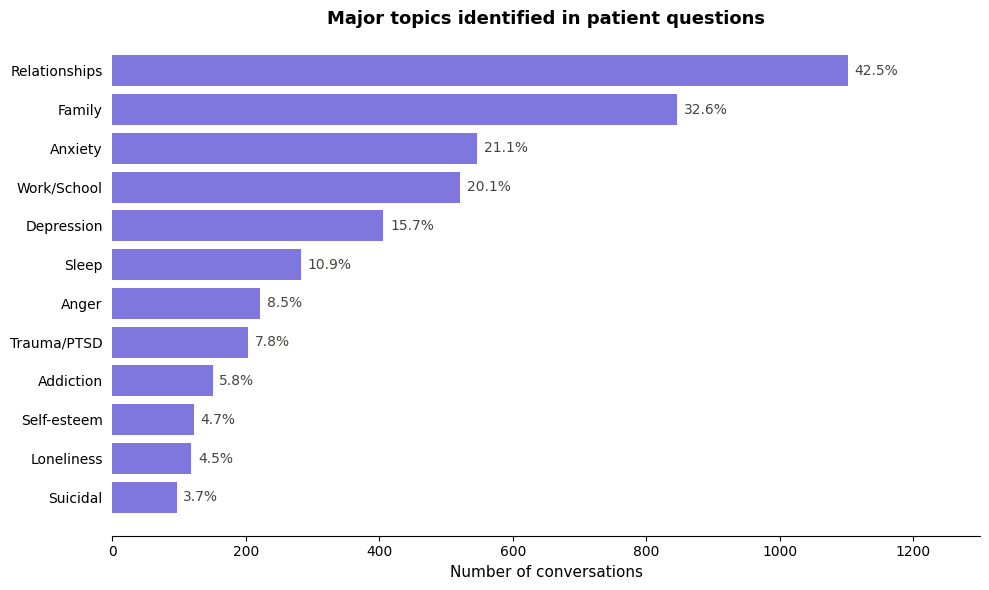


Top keywords matched per topic :

  Anxiety         → anxiety (251),  stress (121),  nervous (84)
  Depression      → depression (188),  depressed (104),  sad (90)
  Relationships   → relationship (393),  love (282),  boyfriend (237)
  Family          → son (312),  family (222),  child (158)
  Self-esteem     → guilt (57),  worthless (39),  shame (18)
  Suicidal        → suicide (43),  suicidal (22),  death (20)
  Addiction       → drinking (67),  addiction (46),  alcohol (46)
  Trauma/PTSD     → abuse (104),  survivor (55),  nightmare (39)
  Sleep           → sleep (109),  rest (81),  insomnia (47)
  Anger           → angry (127),  anger (73),  rage (26)
  Loneliness      → alone (106),  lonely (9),  isolation (2)
  Work/School     → work (286),  school (155),  job (89)


In [7]:

# ── Mental health lexicon ───────────────────────────────────
LEXICON = {
    'Anxiety':     ['anxiety', 'anxious', 'panic', 'worry', 'worried',
                    'nervous', 'fear', 'phobia', 'stress', 'stressed',
                    'overthink', 'dread'],

    'Depression':  ['depression', 'depressed', 'sad', 'sadness', 'hopeless',
                    'empty', 'numb', 'unmotivated', 'despair',
                    'grief', 'miserable'],

    'Relationships': ['relationship', 'partner', 'boyfriend', 'girlfriend',
                      'husband', 'wife', 'marriage', 'divorce', 'breakup',
                      'couple', 'dating', 'love', 'trust'],

    'Family':      ['family', 'mother', 'father', 'parent', 'child',
                    'children', 'son', 'daughter', 'sister', 'brother'],

    'Self-esteem': ['self-esteem', 'confidence', 'worthless', 'shame',
                    'guilt', 'insecure', 'identity', 'self-worth',
                    'self-image', 'inadequate'],

    'Suicidal':    ['suicide', 'suicidal', 'kill myself', 'end my life',
                    'self-harm', 'cutting', 'hurt myself', 'die', 'death'],

    'Addiction':   ['addiction', 'addicted', 'alcohol', 'drugs', 'substance',
                    'drinking', 'smoking', 'marijuana', 'weed', 'cocaine',
                    'gambling'],

    'Trauma/PTSD': ['trauma', 'ptsd', 'abuse', 'assault', 'flashback',
                    'nightmare', 'violence', 'rape', 'harassment', 'survivor'],

    'Sleep':       ['sleep', 'insomnia', 'tired', 'exhausted',
                    'fatigue', 'rest', 'awake', 'sleepless'],

    'Anger':       ['anger', 'angry', 'rage', 'furious', 'irritable',
                    'frustration', 'aggressive', 'temper'],

    'Loneliness':  ['lonely', 'loneliness', 'alone', 'isolated', 'isolation',
                    'disconnected', 'friendless'],

    'Work/School': ['work', 'job', 'career', 'school', 'college', 'university',
                    'boss', 'coworker', 'burnout', 'performance', 'exam',
                    'grades'],
}

# ── Topic detection function ──────────────────────────────────────────────────
def detect_topics(text):
    """
    Returns a list of matching topics for a given text.
    Each keyword belongs to exactly one topic.
    Falls back to ['Other'] if no keyword matches.
    """
    text = str(text).lower()
    found = [topic for topic, keywords in LEXICON.items()
             if any(kw in text for kw in keywords)]
    return found if found else ['Other']

# Apply on patient questions (Context)
df['topics'] = df['Context'].apply(detect_topics)

# ── Topic statistics ──────────────────────────────────────────────────────────
from collections import Counter

all_topics   = [t for topics in df['topics'] for t in topics]
topic_counts = Counter(all_topics)
n_total      = len(df)

topic_table = sorted(topic_counts.items(), key=lambda x: -x[1])
topic_rows  = [
    [topic, count, f"{count / n_total * 100:.1f}%"]
    for topic, count in topic_table
]

print(tabulate(
    topic_rows,
    headers=["Topic", "Conversations", "% of dataset"],
    tablefmt="rounded_outline",
    colalign=("left", "right", "right"),
))

# ── Multi-topic distribution ──────────────────────────────────────────────────
n_multi  = (df['topics'].apply(len) > 1).sum()
n_single = (df['topics'].apply(len) == 1).sum()
n_other  = (df['topics'].apply(lambda x: x == ['Other'])).sum()

print(f"\nConversations with multiple topics : {n_multi}  ({n_multi/n_total*100:.1f}%)")
print(f"Conversations with single topic    : {n_single}  ({n_single/n_total*100:.1f}%)")
print(f"Unmatched (Other)                  : {n_other}  ({n_other/n_total*100:.1f}%)")

# ── Visualisation ─────────────────────────────────────────────────────────────
topics_sorted = [row[0] for row in topic_rows if row[0] != 'Other']
counts_sorted = [topic_counts[t] for t in topics_sorted]
pct_sorted    = [round(c / n_total * 100, 1) for c in counts_sorted]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(topics_sorted[::-1], counts_sorted[::-1],
               color='#7F77DD', edgecolor='none')

for bar, pct in zip(bars, pct_sorted[::-1]):
    ax.text(bar.get_width() + 10, bar.get_y() + bar.get_height() / 2,
            f'{pct}%', va='center', fontsize=10, color='#444441')

ax.set_xlabel("Number of conversations", fontsize=11)
ax.set_title("Major topics identified in patient questions", fontsize=13, fontweight='bold')
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.tick_params(left=False)
ax.set_xlim(0, max(counts_sorted) * 1.18)
plt.tight_layout()
#plt.savefig("topics_distribution.png", dpi=150, bbox_inches='tight')
plt.show()
#print("Chart saved : topics_distribution.png")

# ── Top keywords triggered per topic ─────────────────────────────────────────
print("\nTop keywords matched per topic :\n")
for topic, keywords in LEXICON.items():
    matched = {
        kw: df['Context'].str.lower().str.contains(kw, regex=False).sum()
        for kw in keywords
    }
    top3     = sorted(matched.items(), key=lambda x: -x[1])[:3]
    top3_str = ",  ".join(f"{kw} ({n})" for kw, n in top3)
    print(f"  {topic:<15} → {top3_str}")

Topic Identification using TF-IDF Word Clusters

TF-IDF matrix : 796 questions × 1141 features
LSA matrix    : 796 questions × 50 components
Variance explained by LSA : 24.5%

Selecting optimal number of clusters...

  k= 2  silhouette=0.0222
  k= 3  silhouette=0.0246
  k= 4  silhouette=0.0271
  k= 5  silhouette=0.0327
  k= 6  silhouette=0.0356
  k= 7  silhouette=0.0381
  k= 8  silhouette=0.0427
  k= 9  silhouette=0.0449
  k=10  silhouette=0.0499
  k=11  silhouette=0.0519
  k=12  silhouette=0.0552
  k=13  silhouette=0.0572
  k=14  silhouette=0.0610
  k=15  silhouette=0.0609

Best k by silhouette : 14
Chosen k for analysis : 3

Final silhouette score (k=3) : 0.0246
╭───────────┬─────────────────────────────────────────────┬─────────────┬─────────┬──────────────────────────────────────────────────────╮
│ Cluster   │ Topic label                                 │   Questions │   Share │ Top keywords                                         │
├───────────┼─────────────────────────────────────────────┼─────────────┼─────────┼───────────────

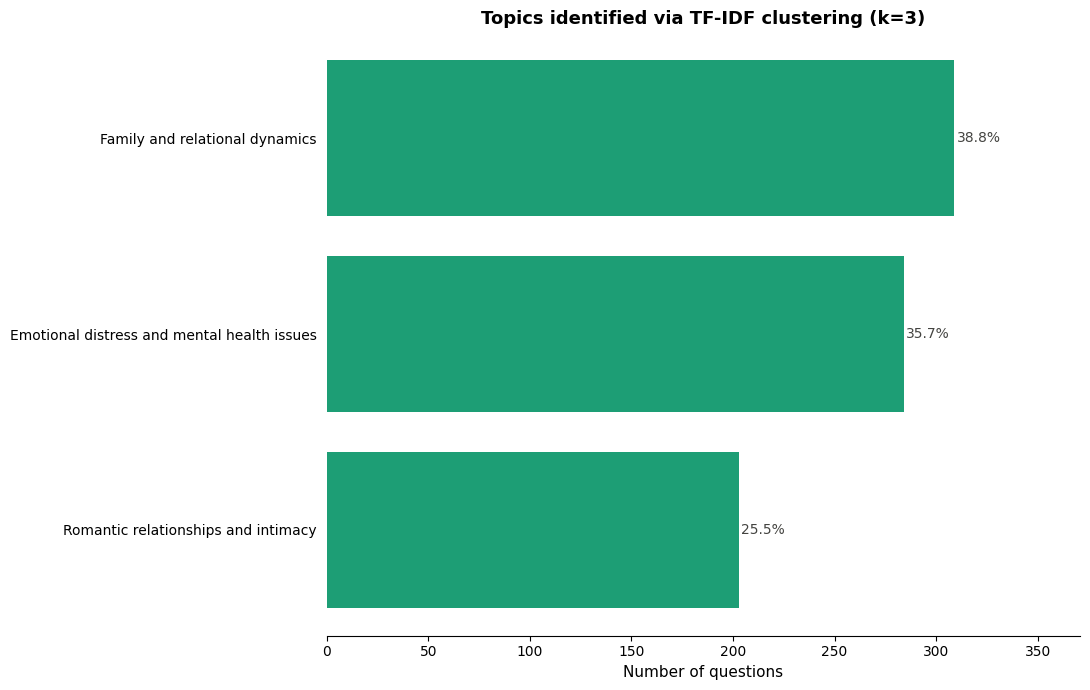

Chart saved : topics_tfidf_clusters.png

Detailed top 10 keywords per cluster :

  Cluster  0 — Emotional distress and mental health issues (n=284)
           anxiety, depression, stop, start, constantly, school, better, right, disorder, scared

  Cluster  1 — Family and relational dynamics (n=309)
           friends, family, child, dad, mom, husband, work, kids, home, mother

  Cluster  2 — Romantic relationships and intimacy (n=203)
           love, relationship, boyfriend, sex, hes, girl, guy, dating, says, men



In [8]:
# ── Step 1 : TF-IDF vectorization ────────────────────────────────────────────
SK_STOPS  = set(TfidfVectorizer(stop_words='english').get_stop_words())
EXTRA_STOPS = set([
    # -------------------------
    # Contractions / noise
    # -------------------------
    "don", "ve", "ll", "nt",
    "im", "ive", "id",
    "dont", "doesnt", "didnt",
    "cant", "wont", "isnt", "wasnt",
    "wouldnt", "couldnt", "shouldnt", "arent", "havent",
    # -------------------------
    # Discourse fillers
    # -------------------------
    "just", "really", "also", "even", "still",
    "actually", "basically", "literally",
    # -------------------------
    # generic nouns
    # -------------------------
    "thing", "things", "something",
    "someone", "anything", "everything", "nothing",
    # -------------------------
    # verbs 
    # -------------------------
    "come", "came", "went",
    "got", "get", "put", "let",
    "took", "take",
    "used", "use",
    "said", "tell", "told", "say",

    # -------------------------
    # Time / structure noise
    # -------------------------
    "time", "day", "days", "year", "years", "ago",
    "long", "since", "last", "first", "now",
    # -------------------------
    # Fillers
    # -------------------------
    "way", "lot", "bit", "kind", "sort",
    "maybe", "probably", "sometimes", "often", "usually",

])
EXTRA_STOPS.update([
    "like", "feel", "feeling", "feel like",
    "know", "think", "people",
    "want", "need", "help",
    "life", "make"
    "going", "started", "getting", "back", "still",
    "times", "thing", "things", "normal", "wrong"
    "stop", "bad", "away", "going", "back",
    "make", "makes", "thing", "things"
])
STOPWORDS = sorted(list(SK_STOPS.union(EXTRA_STOPS)))

vec = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 3),      # BEST for short mental-health texts
    min_df=3,                # remove rare noise
    max_df=0.5,              # remove overly common words 
    sublinear_tf=True,
    stop_words=list(STOPWORDS),
    strip_accents="unicode",
    token_pattern=r"(?u)\b[a-zA-Z]{2,}\b"
)
X = vec.fit_transform(df_users['Context'])
print(f"TF-IDF matrix : {X.shape[0]} questions × {X.shape[1]} features")

# ── Step 2 : LSA dimensionality reduction ─────────────────────────────────────
# TF-IDF is high-dimensional and sparse reduce to 50 dense dimensions
# It captures latent semantic relationships between words

svd    = TruncatedSVD(n_components=50, random_state=42)
X_lsa  = svd.fit_transform(X)
X_norm = Normalizer().fit_transform(X_lsa)  # normalize to unit vectors for cosine distance

print(f"LSA matrix    : {X_norm.shape[0]} questions × {X_norm.shape[1]} components")
print(f"Variance explained by LSA : {svd.explained_variance_ratio_.sum():.1%}")


# ── Step 3 : Select optimal k via silhouette score ────────────────────────────
print("\nSelecting optimal number of clusters...\n")
ks      = range(2, 16)
scores  = []

for k in ks:
    km     = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_norm)
    s      = silhouette_score(X_norm, labels, random_state=42)
    scores.append(s)
    print(f"  k={k:2d}  silhouette={s:.4f}")

best_k = ks[int(np.argmax(scores))]
print(f"\nBest k by silhouette : {best_k}")
print(f"Chosen k for analysis : 3")


# ── Step 4 : Final clustering with k=3 ──────────────────────────────────────
K  = 3
km = KMeans(n_clusters=K, random_state=42, n_init=10, max_iter=500)
df_users = df_users.copy()
df_users['cluster'] = km.fit_predict(X_norm)

final_sil = silhouette_score(X_norm, df_users['cluster'], random_state=42)
print(f"\nFinal silhouette score (k={K}) : {final_sil:.4f}")


# ── Step 5 : Extract top keywords per cluster ─────────────────────────────────
# Project cluster centroids back into TF-IDF space via SVD components
# to retrieve the most representative terms

terms = vec.get_feature_names_out()

def top_keywords(cluster_id, n=10):
    center     = km.cluster_centers_[cluster_id]
    tfidf_proj = center @ svd.components_   # project back to vocab space
    top_idx    = tfidf_proj.argsort()[::-1][:n]
    return [terms[i] for i in top_idx]


# ── Step 6 : Name each cluster based on its top keywords ─────────────────────
# Labels assigned by reading the dominant keywords of each centroid

CLUSTER_LABELS = {
    0:  'Emotional distress and mental health issues',
    1:  'Family and relational dynamics',
    2:  'Romantic relationships and intimacy',
}


# ── Step 7 : Summary table ────────────────────────────────────────────────────
cluster_sizes = df_users['cluster'].value_counts().sort_index()
n_total       = len(df_users)

rows = []
for c in range(K):
    keywords = top_keywords(c, n=6)
    size     = cluster_sizes[c]
    rows.append([
        f"Cluster {c}",
        CLUSTER_LABELS[c],
        size,
        f"{size/n_total*100:.1f}%",
        ", ".join(keywords)
    ])

# Sort by size descending
rows_sorted = sorted(rows, key=lambda x: -x[2])

print(tabulate(
    rows_sorted,
    headers=["Cluster", "Topic label", "Questions", "Share", "Top keywords"],
    tablefmt="rounded_outline",
    colalign=("left", "left", "right", "right", "left"),
))


# ── Step 8 : Visualisation ────────────────────────────────────────────────────
labels_sorted = [r[1] for r in rows_sorted]
sizes_sorted  = [r[2] for r in rows_sorted]
pcts_sorted   = [float(r[3].replace('%','')) for r in rows_sorted]

fig, ax = plt.subplots(figsize=(11, 7))
bars = ax.barh(labels_sorted[::-1], sizes_sorted[::-1],
               color='#1D9E75', edgecolor='none')

for bar, pct in zip(bars, pcts_sorted[::-1]):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height() / 2,
            f'{pct}%', va='center', fontsize=10, color='#444441')

ax.set_xlabel("Number of questions", fontsize=11)
ax.set_title("Topics identified via TF-IDF clustering (k=3)", fontsize=13, fontweight='bold')
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.tick_params(left=False)
ax.set_xlim(0, max(sizes_sorted) * 1.2)
plt.tight_layout()
plt.savefig("topics_tfidf_clusters.png", dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved : topics_tfidf_clusters.png")

# ── Step 9 : Detailed keywords per cluster ────────────────────────────────────
print("\nDetailed top 10 keywords per cluster :\n")
for c in range(K):
    size     = cluster_sizes[c]
    keywords = top_keywords(c, n=10)
    print(f"  Cluster {c:2d} — {CLUSTER_LABELS[c]:<25} (n={size:3d})")
    print(f"           {', '.join(keywords)}\n")

TOPIC IDENTIFICATION — WORD EMBEDDINGS CLUSTERING

Loading SentenceTransformer model...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Encoding patient questions...


Batches:   0%|          | 0/13 [00:00<?, ?it/s]


Sentence embeddings : 796 questions × 384 dimensions

Selecting optimal number of clusters...

  k= 2  silhouette=0.0430
  k= 3  silhouette=0.0402
  k= 4  silhouette=0.0371
  k= 5  silhouette=0.0330
  k= 6  silhouette=0.0300
  k= 7  silhouette=0.0285
  k= 8  silhouette=0.0299
  k= 9  silhouette=0.0297
  k=10  silhouette=0.0267
  k=11  silhouette=0.0277
  k=12  silhouette=0.0284
  k=13  silhouette=0.0248
  k=14  silhouette=0.0251
  k=15  silhouette=0.0249

Best k by silhouette : 2
Chosen k for analysis : 8
Final silhouette score (k=8) : 0.0299

Clusters and top keywords (for manual labeling):

  Cluster  0 (n=111) : husband, married, relationship, hes, love, wife, cheated, says
  Cluster  1 (n= 86) : therapist, counseling, child, therapy, counselor, issues, abused, depression
  Cluster  2 (n=121) : love, relationship, boyfriend, guy, dating, hes, girlfriend, friends
  Cluster  3 (n=101) : mom, dad, child, mother, shes, family, parents, father
  Cluster  4 (n= 95) : anxiety, depression,

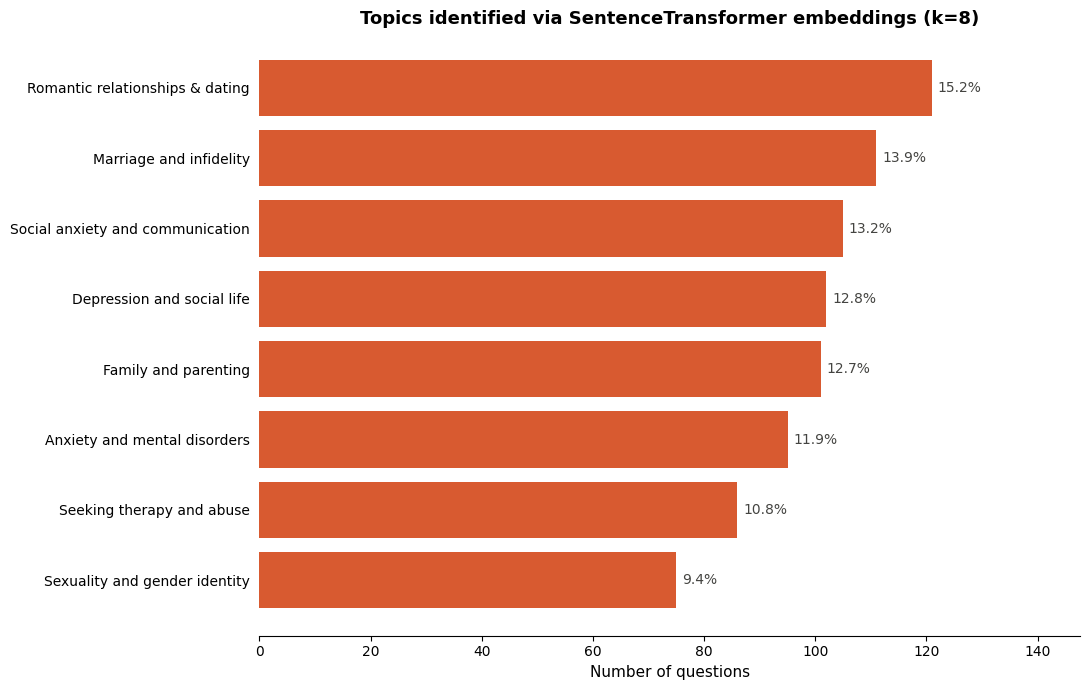

Chart saved : topics_embeddings_clusters.png


In [9]:
# ── Step 1 : Encode patient questions with SentenceTransformer ────────────────
print("Loading SentenceTransformer model...")
model = SentenceTransformer('all-MiniLM-L6-v2')
 
print("Encoding patient questions...")
sent_emb = model.encode(
    df_users['Context'].tolist(),
    show_progress_bar=True,
    batch_size=64
)
sent_emb = Normalizer().fit_transform(sent_emb)
print(f"\nSentence embeddings : {sent_emb.shape[0]} questions × {sent_emb.shape[1]} dimensions")
 

# ── Step 2 : Select optimal k via silhouette score ───────────────────────────
print("\nSelecting optimal number of clusters...\n")
ks     = range(2, 16)
scores = []
 
for k in ks:
    km     = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(sent_emb)
    s      = silhouette_score(sent_emb, labels, random_state=42)
    scores.append(s)
    print(f"  k={k:2d}  silhouette={s:.4f}")
 
best_k = ks[int(np.argmax(scores))]
print(f"\nBest k by silhouette : {best_k}")
 
# With sentence embeddings on short texts, silhouette scores are uniformly low
K = max(best_k, 8)
print(f"Chosen k for analysis : {K}")
 

# ── Step 3 : Final clustering with chosen k ───────────────────────────────────
 
km = KMeans(n_clusters=K, random_state=42, n_init=10, max_iter=300)
df_users = df_users.copy()
df_users['cluster'] = km.fit_predict(sent_emb)
 
final_sil     = silhouette_score(sent_emb, df_users['cluster'], random_state=42)
cluster_sizes = df_users['cluster'].value_counts().sort_index()
 
print(f"Final silhouette score (k={K}) : {final_sil:.4f}")
 
# ── Step 4 : Top keywords per cluster via TF-IDF on cluster members ──────────
# Extended stopwords to suppress generic words that dominate short texts

 
vec = TfidfVectorizer(
    max_features=5000,
    stop_words=list(set(
        TfidfVectorizer(stop_words='english').get_stop_words()
    ).union(set(EXTRA_STOPS))),
    ngram_range=(1, 2),
    min_df=2
)
vec.fit(df_users['Context'])
terms = vec.get_feature_names_out()
 
def top_keywords_cluster(cluster_id, n=8):
    """
    Returns the top n TF-IDF keywords for questions in a given cluster.
    Computes mean TF-IDF vector across all cluster members.
    """
    mask      = df_users['cluster'] == cluster_id
    texts     = df_users.loc[mask, 'Context'].tolist()
    X_cluster = vec.transform(texts)
    mean_tfidf = X_cluster.mean(axis=0).A1
    top_idx    = mean_tfidf.argsort()[::-1][:n]
    return [terms[i] for i in top_idx]
 

# ── Step 5 : Print clusters with keywords for manual labeling ─────────────────
print("\nClusters and top keywords (for manual labeling):\n")
for c in range(K):
    size     = cluster_sizes[c]
    keywords = top_keywords_cluster(c, n=8)
    print(f"  Cluster {c:2d} (n={size:3d}) : {', '.join(keywords)}")
 
# ── Step 6 : Assign topic labels based on keywords ───────────────────────────
# Labels assigned by reading the dominant keywords of each cluster
# Adjust CLUSTER_LABELS after running Step 5 if needed
 
# Labels assigned from reading cluster keywords 
CLUSTER_LABELS = {
    0: 'Marriage and infidelity',            # husband, married, cheated, wife
    1: 'Seeking therapy and abuse',          # therapist, counseling, therapy, counselor, abused
    2: 'Romantic relationships & dating',  # love, boyfriend, dating, guy, girlfriend
    3: 'Family and parenting',               # mom, dad, child, mother, family, parents
    4: 'Anxiety and mental disorders',       # anxiety, depression, attacks, panic, disorder
    5: 'Social anxiety and communication',   # people, thoughts, friends, talking, tell
    6: 'Sexuality and gender identity',      # sex, girl, men, love, gay
    7: 'Depression and social life',         # life, school, friends, sad, depressed
}
 

# ── Step 7 : Summary table ───────────────────────────────────────────────────
n_total = len(df_users)
rows    = []
for c in range(K):
    keywords = top_keywords_cluster(c, n=6)
    size     = cluster_sizes[c]
    rows.append([
        f"Cluster {c}",
        CLUSTER_LABELS[c],
        size,
        f"{size/n_total*100:.1f}%",
        ", ".join(keywords)
    ])
 
rows_sorted = sorted(rows, key=lambda x: -x[2])
 
print(tabulate(
    rows_sorted,
    headers=["Cluster", "Topic label", "Questions", "Share", "Top keywords"],
    tablefmt="rounded_outline",
    colalign=("left", "left", "right", "right", "left"),
))
 

# ── Step 8 : Visualisation ───────────────────────────────────────────────────
labels_sorted = [r[1] for r in rows_sorted]
sizes_sorted  = [r[2] for r in rows_sorted]
pcts_sorted   = [float(r[3].replace('%', '')) for r in rows_sorted]
 
fig, ax = plt.subplots(figsize=(11, 7))
bars = ax.barh(labels_sorted[::-1], sizes_sorted[::-1],
               color='#D85A30', edgecolor='none')
 
for bar, pct in zip(bars, pcts_sorted[::-1]):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height() / 2,
            f'{pct}%', va='center', fontsize=10, color='#444441')
 
ax.set_xlabel("Number of questions", fontsize=11)
ax.set_title(f"Topics identified via SentenceTransformer embeddings (k={K})",
             fontsize=13, fontweight='bold')
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.tick_params(left=False)
ax.set_xlim(0, max(sizes_sorted) * 1.22)
plt.tight_layout()
plt.savefig("topics_embeddings_clusters.png", dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved : topics_embeddings_clusters.png")

TOPIC IDENTIFICATION — LDA


Perplexity by number of topics :

  n_topics= 3  perplexity=818.3
  n_topics= 5  perplexity=901.0
  n_topics= 8  perplexity=1022.2
  n_topics=10  perplexity=1064.5
  n_topics=12  perplexity=1168.9
  n_topics=15  perplexity=1259.0

Lowest perplexity at n_topics=3
Note : on this corpus, mental health themes heavily overlap in vocabulary.
Chosen n_topics : 6
Final perplexity (n_topics=6) : 1469.8

Top 10 words per topic (for manual labeling) :

  Topic  0 : anxiety, depression, shes, boyfriend, mom, family, parents, disorder, relationship, work
  Topic  1 : therapist, money, phone, relationship, friends, stop, job, work, trying, thought
  Topic  2 : mother, mom, dad, son, child, relationship, wife, family, live, friend
  Topic  3 : girlfriend, thinking, hes, thoughts, stop, family, girl, wrong, happy, sleep
  Topic  4 : love, hes, sex, relationship, boyfriend, husband, guy, talking, night, work
  Topic  5 : school, friends, right, high, live, afraid, kids, fix, early, wants


╭─────────┬

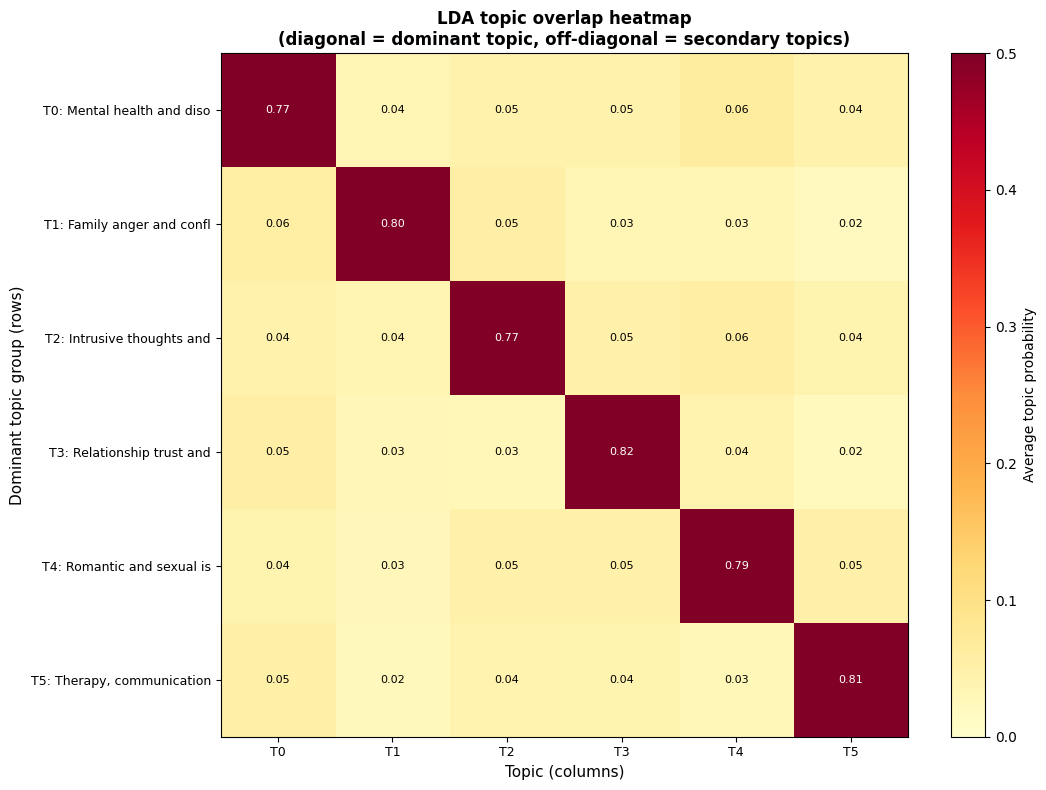

Heatmap saved : topics_lda_heatmap.png


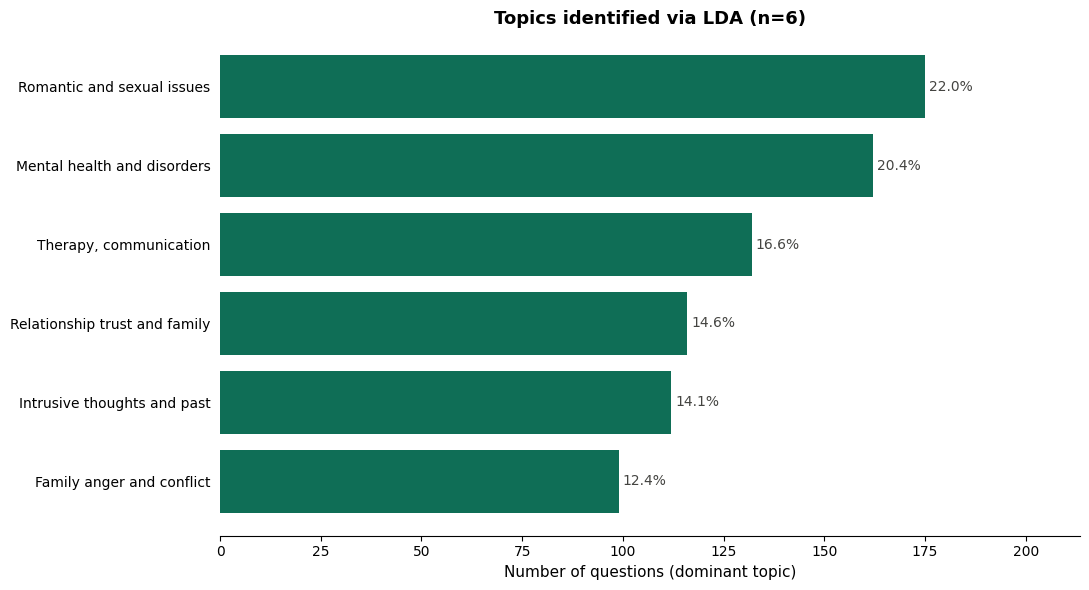

Chart saved : topics_lda_distribution.png


In [11]:

# ── Step 1 : Build document-term matrix ──────────────────
EXTRA_STOPS.update([
    "know", "like", "makes"
])
EXTRA_STOPS.update([
    "go", "going", "get", "got", "make", "makes",
    "say", "says", "tell", "talk", "think"
])
SK_STOPS  = set(TfidfVectorizer(stop_words='english').get_stop_words())
STOPWORDS = SK_STOPS.union(EXTRA_STOPS)

cv = CountVectorizer(
    max_features=3000,
    stop_words=list(STOPWORDS),
    min_df=3,           # word must appear in at least 3 documents
    max_df=0.5,         # word must not appear in more than 50% of documents
    ngram_range=(1, 1),  # unigrams
    token_pattern=r"(?u)\b[a-zA-Z]{3,}\b"
)
X     = cv.fit_transform(df_users['Context'])
terms = cv.get_feature_names_out()

# ── Step 2 : Select optimal n_topics via perplexity ──────────────────────────
# Perplexity measures how surprised the model is by the data
# how well the trained LDA model can predict the words in documents.
#
#   Low perplexity  = model fits the data well
#   High perplexity = model is struggling to explain the data
#
# Important : perplexity always decreases as n_topics grows when evaluated
# on training data it is not a reliable selection criterion alone.
# We look for the elbow where adding more topics brings diminishing returns,
# and balance it with human readability of the resulting topics.

print("\nPerplexity by number of topics :\n")
n_topics_range = [3, 5, 8, 10, 12, 15]
perplexities   = []

for n in n_topics_range:
    lda_test = LatentDirichletAllocation(
        n_components=n, random_state=42,
        max_iter=30, learning_method='batch'
    )
    lda_test.fit(X)
    perp = lda_test.perplexity(X)
    perplexities.append(perp)
    print(f"  n_topics={n:2d}  perplexity={perp:.1f}")

best_n = n_topics_range[int(np.argmin(perplexities))]
print(f"\nLowest perplexity at n_topics={best_n}")
print(f"Note : on this corpus, mental health themes heavily overlap in vocabulary.")
print(f"Chosen n_topics : 6")


# ── Step 3 : Train final LDA model ───────────────────────────────────────────
N_TOPICS = 6

lda = LatentDirichletAllocation(
    n_components=N_TOPICS,
    random_state=42,
    max_iter=40,             # more iterations for better convergence
    learning_method='batch', 
    learning_decay=0.7,      # controls forgetting rate
    doc_topic_prior=0.1,     # alpha : low = sparse doc-topic distributions
    topic_word_prior=0.01    # beta  : low = sparse topic-word distributions
)
lda.fit(X)
print(f"Final perplexity (n_topics={N_TOPICS}) : {lda.perplexity(X):.1f}")

# ── Step 4 : Extract top words per topic ─────────────────────────────────────
FILTER = {"feel","want","think","need","help","people","life"}

def clean_top_words(words):
    return [w for w in words if w not in FILTER]

def top_words_lda(topic_idx, n=10):
    """Returns top n words for a given LDA topic."""
    topic   = lda.components_[topic_idx]
    top_idx = topic.argsort()[::-1][:n]
    return [terms[i] for i in top_idx]

print("\nTop 10 words per topic (for manual labeling) :\n")
for i in range(N_TOPICS):
    words = top_words_lda(i, n=10)
    words=clean_top_words(words)
    print(f"  Topic {i:2d} : {', '.join(words)}")


# ── Step 5 : Assigning topic labels ─────────────────────────────────────────────

TOPIC_LABELS = {
    0: 'Mental health and disorders',      # anxiety, depression, disorder, child, children
    1: 'Family anger and conflict',        # mother, parents, angry, anger, wife
    2: 'Intrusive thoughts and past',      # away, friends, stop, thoughts, past
    3: 'Relationship trust and family',    # love, hes, kids, work, family, wants, trust
    4: 'Romantic and sexual issues',       # boyfriend, sex, love, wrong, feeling, girlfriend
    5: 'Therapy, communication',      # therapist, house, talking, night, phone, stop
}

# ── Step 6 : Get topic distributions per document ────────────────────────────
# LDA gives a probability vector per document — soft assignment
doc_topics = lda.transform(X)   # shape: (796, N_TOPICS)
df_users   = df_users.copy()
df_users['lda_dominant_topic'] = doc_topics.argmax(axis=1)
df_users['lda_topic_proba']    = doc_topics.max(axis=1)


# ── Step 7 : Summary table ───────────────────────────────────────────────────
n_total      = len(df_users)
topic_counts = df_users['lda_dominant_topic'].value_counts().sort_index()

rows = []
for t in range(N_TOPICS):
    size     = topic_counts.get(t, 0)
    words    = top_words_lda(t, n=5)
    avg_prob = doc_topics[df_users['lda_dominant_topic'] == t, t].mean()
    rows.append([
        f"Topic {t}",
        TOPIC_LABELS[t],
        size,
        f"{size/n_total*100:.1f}%",
        f"{avg_prob:.2f}",
        ", ".join(words)
    ])

rows_sorted = sorted(rows, key=lambda x: -x[2])

print("\n")
print(tabulate(
    rows_sorted,
    headers=["Topic", "Label", "Questions", "Share", "Avg prob", "Top words"],
    tablefmt="rounded_outline",
    colalign=("left", "left", "right", "right", "right", "left"),
))

# ── Step 8 : Multi-topic analysis (soft assignment) ──────────────────────────
# LDA's key advantage — show topics that co-occur in the same question

THRESHOLD = 0.15   # topic is "present" if probability > 15%

df_users['lda_all_topics'] = [
    [TOPIC_LABELS[i] for i, p in enumerate(probs) if p > THRESHOLD]
    for probs in doc_topics
]

n_multi  = (df_users['lda_all_topics'].apply(len) > 1).sum()
n_single = (df_users['lda_all_topics'].apply(len) == 1).sum()
n_none   = (df_users['lda_all_topics'].apply(len) == 0).sum()

print(f"\nWith threshold = {THRESHOLD} :")
print(f"  Questions covering multiple topics : {n_multi}  ({n_multi/n_total*100:.1f}%)")
print(f"  Questions with single topic        : {n_single}  ({n_single/n_total*100:.1f}%)")
print(f"  Questions below threshold          : {n_none}  ({n_none/n_total*100:.1f}%)")


# ── Step 9 : Topic distribution heatmap ──────────────────────────────────────
# Shows average topic weight per dominant topic group — reveals overlap
# Diagonal = dominant topic weight
# Off-diagonal = secondary topic weights (overlap between themes)

avg_by_dominant = np.zeros((N_TOPICS, N_TOPICS))
for dominant in range(N_TOPICS):
    mask = df_users['lda_dominant_topic'] == dominant
    if mask.sum() > 0:
        avg_by_dominant[dominant] = doc_topics[mask].mean(axis=0)

fig, ax = plt.subplots(figsize=(11, 8))
im = ax.imshow(avg_by_dominant, cmap='YlOrRd', aspect='auto', vmin=0, vmax=0.5)
plt.colorbar(im, ax=ax, label='Average topic probability')

ax.set_xticks(range(N_TOPICS))
ax.set_yticks(range(N_TOPICS))
ax.set_xticklabels([f"T{i}" for i in range(N_TOPICS)], fontsize=9)
ax.set_yticklabels([f"T{i}: {TOPIC_LABELS[i][:22]}" for i in range(N_TOPICS)], fontsize=9)
ax.set_xlabel("Topic (columns)", fontsize=11)
ax.set_ylabel("Dominant topic group (rows)", fontsize=11)
ax.set_title("LDA topic overlap heatmap\n(diagonal = dominant topic, off-diagonal = secondary topics)",
             fontsize=12, fontweight='bold')

for i in range(N_TOPICS):
    for j in range(N_TOPICS):
        ax.text(j, i, f"{avg_by_dominant[i,j]:.2f}",
                ha='center', va='center', fontsize=8,
                color='black' if avg_by_dominant[i,j] < 0.3 else 'white')

plt.tight_layout()
plt.savefig("topics_lda_heatmap.png", dpi=150, bbox_inches='tight')
plt.show()
print("Heatmap saved : topics_lda_heatmap.png")


# ── Step 10 : Bar chart dominant topic distribution ──────────────────────────
labels_sorted = [r[1] for r in rows_sorted]
sizes_sorted  = [r[2] for r in rows_sorted]
pcts_sorted   = [float(r[3].replace('%', '')) for r in rows_sorted]

fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.barh(labels_sorted[::-1], sizes_sorted[::-1],
               color='#0F6E56', edgecolor='none')

for bar, pct in zip(bars, pcts_sorted[::-1]):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height() / 2,
            f'{pct}%', va='center', fontsize=10, color='#444441')

ax.set_xlabel("Number of questions (dominant topic)", fontsize=11)
ax.set_title(f"Topics identified via LDA (n={N_TOPICS})", fontsize=13, fontweight='bold')
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.tick_params(left=False)
ax.set_xlim(0, max(sizes_sorted) * 1.22)
plt.tight_layout()
plt.savefig("topics_lda_distribution.png", dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved : topics_lda_distribution.png")




Topic identification  comparison of all methods
Four approaches were applied to identify major subjects across 796 patient questions. Each method brings a different perspective on the same data.

Lexicon (rule-based, 12 topics)
The only method that produces clinically named categories with precise counts. Relationships (42.5%), Family (32.6%) and Anxiety (21.1%) are the three dominant themes. The multi-label design allows one question to match several topics simultaneously, which explains why percentages sum to more than 100%. The limitation remains that keyword matching is rigid  Work/School (20.1%) is likely inflated because the word work appears in many non professional contexts, and synonyms like worried and anxious are counted separately unless manually listed together. The Other category (14.6%) represents questions that matched no keyword, signaling gaps in the lexicon coverage.
Opinion : the lexicon produces the most clinically interpretable output but the distribution is uneven  Relationships dominates at 42.5% while Suicidal sits at 3.7%. This reflects the dataset composition rather than a flaw in the method. Best used as a reference baseline.

TF-IDF + KMeans (k=3)
With preprocessing applied (extended stopwords, ngram_range 1–3, max_df=0.5, LSA reduction), k=3 produces a well-balanced and clean separation  38.8%, 35.7%, 25.5%. The three clusters are genuinely distinct with no overlap in top keywords. LSA played a key role in separating the semantic space by capturing latent relationships between words rather than treating each term independently.
Opinion : the balance is good and the labels are coherent.

SentenceTransformer / BERT + KMeans (k=8)
The most granular and semantically precise output. Eight clusters with sizes ranging from 75 to 121 questions  the most balanced distribution of all methods. Every cluster has substantive keywords with no stopword noise. Notable clusters that do not appear in the lexicon at all : Seeking therapy & abuse (10.8%) and Marriage & infidelity (13.9%), which BERT correctly separates from general romantic relationships by understanding that cheated, married, husband and wife live in a different semantic space than boyfriend, dating, love.
Opinion : this is the best overall result. The smallest cluster (Sexuality & gender identity, 75 questions, 9.4%) is still meaningful and well-defined, confirming that k=8 does not over-segment the data. BERT's pretraining on billions of sentences fully compensates for the small corpus size.

LDA (n=6)
LDA produces a soft assignment  each question receives a probability distribution over all topics rather than a single hard label. Average probabilities range from 0.77 to 0.82, indicating solid model confidence. The soft assignment reveals that a meaningful share of questions genuinely span multiple topics simultaneously, which no clustering method can capture. Some thematic overlap is visible between topics containing both romantic and mental health vocabulary, which reflects the intrinsic structure of the dataset rather than a modeling error.
Opinion : LDA is the only method that honestly represents the multi-topic nature of mental health conversations. Its unique contribution is quantifying the overlap  27.4% of questions belong to more than one topic simultaneously. However, with n=6, some topics bleed into each other due to the heavy vocabulary overlap inherent to this corpus.

No single method is universally superior. The lexicon is best for reporting against known clinical categories. TF-IDF provides a fast and interpretable high-level view. BERT produces the cleanest and most balanced clusters for downstream NLP tasks. LDA is the only method that captures the multi-topic nature of the questions , and its soft probabilities reveal a key structural property of this dataset : mental health conversations are fundamentally overlapping, with the same vocabulary spanning anxiety, relationships, and family regardless of the primary concern.